# Bootstrap验证 - 30年PAWN敏感性分析

本notebook对30年分年度PAWN敏感性分析结果进行Bootstrap统计验证。

**目标**:
1. 评估各气候区30年PAWN结果的统计显著性
2. 计算95%置信区间
3. 估计结果的稳定性（标准误差）

**方法**:
- 对每个年份-气候区组合分别进行Bootstrap重采样
- Bootstrap次数: 1000次
- 使用与30y_PAWN.ipynb完全相同的数据和方法

## 0. 导入库和设置

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ks_2samp
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子以保证可重复性
np.random.seed(42)

# 设置绘图样式
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# Bootstrap配置参数
N_BOOTSTRAP = 1000  # Bootstrap重采样次数
CONFIDENCE_LEVEL = 0.95  # 置信水平

# 创建输出目录
output_dir = Path('output/bootstrap_30y_PAWN')
output_dir.mkdir(parents=True, exist_ok=True)

print("✓ 库导入完成")
print(f"✓ Bootstrap次数: {N_BOOTSTRAP}")
print(f"✓ 置信水平: {CONFIDENCE_LEVEL}")
print(f"✓ 分析方法: PAWN")
print(f"✓ 输出目录: {output_dir}")

✓ 库导入完成
✓ Bootstrap次数: 1000
✓ 置信水平: 0.95
✓ 分析方法: PAWN
✓ 输出目录: output\bootstrap_30y_PAWN


## 1. 读取数据

In [4]:
# 读取已打好气候区标签的30年数据（与30y_PAWN.ipynb相同）
classic_path = Path('data/preprocessed/preprocessed_with_zones/classic_with_climate_zones_30y.csv')
lpj_path = Path('data/preprocessed/preprocessed_with_zones/lpj_guess_with_climate_zones_30y.csv')

print("读取已打好气候区标签的30年数据...")
classic_df = pd.read_csv(classic_path)
lpj_df = pd.read_csv(lpj_path)

print(f"\nCLASSIC数据: {len(classic_df):,} 行")
print(f"LPJ-GUESS数据: {len(lpj_df):,} 行")

# 定义变量
input_vars = ['precipitation', 'lai']
output_vars = ['evapotrans', 'tran', 'evspsblveg', 'evspsblsoi']
climate_zones = ['HW', 'HD', 'CW', 'CD']
zone_names = {
    'HW': 'Hot-Wet',
    'HD': 'Hot-Dry',
    'CW': 'Cold-Wet',
    'CD': 'Cold-Dry'
}

# 获取年份列表
years = sorted(classic_df['time'].unique())

print(f"\n时间范围: {years[0]}-{years[-1]} ({len(years)}年)")
print(f"气候区: {climate_zones}")
print(f"输入变量: {input_vars}")
print(f"输出变量: {output_vars}")

# 验证数据一致性
print("\n" + "="*80)
print("数据验证")
print("="*80)

for df_name, df in [('CLASSIC', classic_df), ('LPJ-GUESS', lpj_df)]:
    print(f"\n{df_name}:")
    print(f"  气候区样本量:")
    for zone in climate_zones:
        count = len(df[df['climate_zone'] == zone])
        print(f"    {zone}: {count:,}")

读取已打好气候区标签的30年数据...

CLASSIC数据: 1,824,800 行
LPJ-GUESS数据: 1,751,623 行

时间范围: 1991-2020 (30年)
气候区: ['HW', 'HD', 'CW', 'CD']
输入变量: ['precipitation', 'lai']
输出变量: ['evapotrans', 'tran', 'evspsblveg', 'evspsblsoi']

数据验证

CLASSIC:
  气候区样本量:
    HW: 397,473
    HD: 354,820
    CW: 671,688
    CD: 399,802

LPJ-GUESS:
  气候区样本量:
    HW: 398,518
    HD: 356,292
    CW: 671,248
    CD: 321,060


## 2. 定义PAWN方法函数

复用30y_PAWN.ipynb中的PAWN函数定义

In [5]:
def calculate_pawn_index(df, input_var, output_var, n_bins=10):
    """
    计算PAWN敏感性指数
    
    PAWN方法使用Kolmogorov-Smirnov统计量来衡量条件分布与无条件分布的差异
    
    参数:
        df: 数据框
        input_var: 输入变量名
        output_var: 输出变量名
        n_bins: 分箱数量（默认10）
    
    返回:
        dict: {'median': PAWN中位数, 'max': PAWN最大值}
    """
    # 无条件输出分布
    y_unconditional = df[output_var].values
    
    # 将输入变量分箱
    try:
        bins = pd.qcut(df[input_var], q=n_bins, duplicates='drop')
    except ValueError:
        bins = pd.cut(df[input_var], bins=n_bins)
    
    # 计算每个bin的KS统计量
    ks_stats = []
    for bin_label in bins.cat.categories:
        y_conditional = df.loc[bins == bin_label, output_var].values
        if len(y_conditional) < 10:
            continue
        ks_stat, p_value = ks_2samp(y_unconditional, y_conditional)
        ks_stats.append(ks_stat)
    
    if len(ks_stats) == 0:
        return {'median': 0, 'max': 0}
    
    return {
        'median': np.median(ks_stats),
        'max': np.max(ks_stats)
    }

print("✓ PAWN函数已定义")

✓ PAWN函数已定义


## 3. Bootstrap分析主函数

In [8]:
def bootstrap_pawn_single(zone_data, input_var, output_var, 
                          n_bootstrap=1000, random_seed=None):
    """
    对单个输入-输出变量组合进行PAWN Bootstrap分析
    
    Parameters:
    -----------
    zone_data : DataFrame
        单个年份-气候区的数据
    input_var : str
        输入变量名
    output_var : str
        输出变量名
    n_bootstrap : int
        Bootstrap重采样次数
    random_seed : int
        随机种子
    
    Returns:
    --------
    dict with bootstrap results
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    
    n_samples = len(zone_data)
    
    # 计算原始值（点估计）
    original_pawn = calculate_pawn_index(zone_data, input_var, output_var)
    
    # Bootstrap重采样
    pawn_boots = []
    
    for b in range(n_bootstrap):
        # 有放回抽样
        boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
        boot_data = zone_data.iloc[boot_indices].reset_index(drop=True)
        
        # 计算PAWN
        pawn_boot = calculate_pawn_index(boot_data, input_var, output_var)
        pawn_boots.append(pawn_boot['median'])
    
    # 转换为numpy数组
    pawn_boots = np.array(pawn_boots)
    
    # 计算置信区间
    alpha = 1 - CONFIDENCE_LEVEL
    pawn_ci = np.percentile(pawn_boots, [alpha/2*100, (1-alpha/2)*100])
    
    return {
        'n_samples': n_samples,
        'pawn_original': original_pawn['median'],
        'pawn_boot_mean': np.mean(pawn_boots),
        'pawn_boot_std': np.std(pawn_boots),
        'pawn_ci_lower': pawn_ci[0],
        'pawn_ci_upper': pawn_ci[1],
        'pawn_significant': not (pawn_ci[0] <= 0 <= pawn_ci[1])
    }

print("✓ Bootstrap分析函数已定义")

✓ Bootstrap分析函数已定义


## 4. 执行Bootstrap分析

按年份-气候区分别进行Bootstrap验证

### 4.1 CLASSIC模型

In [9]:
print("="*80)
print("CLASSIC模型 - 30年Bootstrap分析")
print("="*80)

classic_bootstrap_results = []

for year in tqdm(years, desc="年份进度"):
    # 筛选该年的数据
    year_data = classic_df[classic_df['time'] == year].copy()
    
    for zone in climate_zones:
        # 获取该年份-气候区数据
        zone_data = year_data[year_data['climate_zone'] == zone].copy()
        
        if len(zone_data) < 50:
            continue
        
        # 对每个输入-输出组合进行bootstrap
        for output_var in output_vars:
            for input_var in input_vars:
                # 执行bootstrap
                boot_result = bootstrap_pawn_single(
                    zone_data, input_var, output_var,
                    n_bootstrap=100,
                    random_seed=42
                )
                
                # 保存结果
                result_record = {
                    'model': 'CLASSIC',
                    'year': year,
                    'climate_zone': zone,
                    'output_var': output_var,
                    'input_var': input_var,
                    **boot_result
                }
                classic_bootstrap_results.append(result_record)

# 转换为DataFrame
classic_bootstrap_df = pd.DataFrame(classic_bootstrap_results)

print(f"\n✓ CLASSIC Bootstrap分析完成！共 {len(classic_bootstrap_df):,} 个结果")
print(f"\n前10行:")
print(classic_bootstrap_df.head(10))

CLASSIC模型 - 30年Bootstrap分析


年份进度: 100%|██████████| 30/30 [29:12<00:00, 58.43s/it]


✓ CLASSIC Bootstrap分析完成！共 960 个结果

前10行:
     model  year climate_zone  output_var      input_var  n_samples  \
0  CLASSIC  1991           HW  evapotrans  precipitation      13251   
1  CLASSIC  1991           HW  evapotrans            lai      13251   
2  CLASSIC  1991           HW        tran  precipitation      13251   
3  CLASSIC  1991           HW        tran            lai      13251   
4  CLASSIC  1991           HW  evspsblveg  precipitation      13251   
5  CLASSIC  1991           HW  evspsblveg            lai      13251   
6  CLASSIC  1991           HW  evspsblsoi  precipitation      13251   
7  CLASSIC  1991           HW  evspsblsoi            lai      13251   
8  CLASSIC  1991           HD  evapotrans  precipitation      11829   
9  CLASSIC  1991           HD  evapotrans            lai      11829   

   pawn_original  pawn_boot_mean  pawn_boot_std  pawn_ci_lower  pawn_ci_upper  \
0       0.299868        0.302152       0.007335       0.287610       0.315887   
1       0.3767

### 4.2 LPJ-GUESS模型

In [10]:
print("="*80)
print("LPJ-GUESS模型 - 30年Bootstrap分析")
print("="*80)

lpj_bootstrap_results = []

for year in tqdm(years, desc="年份进度"):
    # 筛选该年的数据
    year_data = lpj_df[lpj_df['time'] == year].copy()
    
    for zone in climate_zones:
        # 获取该年份-气候区数据
        zone_data = year_data[year_data['climate_zone'] == zone].copy()
        
        if len(zone_data) < 50:
            continue
        
        # 对每个输入-输出组合进行bootstrap
        for output_var in output_vars:
            for input_var in input_vars:
                # 执行bootstrap
                boot_result = bootstrap_pawn_single(
                    zone_data, input_var, output_var,
                    n_bootstrap=100,
                    random_seed=42
                )
                
                # 保存结果
                result_record = {
                    'model': 'LPJ-GUESS',
                    'year': year,
                    'climate_zone': zone,
                    'output_var': output_var,
                    'input_var': input_var,
                    **boot_result
                }
                lpj_bootstrap_results.append(result_record)

# 转换为DataFrame
lpj_bootstrap_df = pd.DataFrame(lpj_bootstrap_results)

print(f"\n✓ LPJ-GUESS Bootstrap分析完成！共 {len(lpj_bootstrap_df):,} 个结果")
print(f"\n前10行:")
print(lpj_bootstrap_df.head(10))

LPJ-GUESS模型 - 30年Bootstrap分析


年份进度: 100%|██████████| 30/30 [30:10<00:00, 60.33s/it]


✓ LPJ-GUESS Bootstrap分析完成！共 960 个结果

前10行:
       model  year climate_zone  output_var      input_var  n_samples  \
0  LPJ-GUESS  1991           HW  evapotrans  precipitation      13298   
1  LPJ-GUESS  1991           HW  evapotrans            lai      13298   
2  LPJ-GUESS  1991           HW        tran  precipitation      13298   
3  LPJ-GUESS  1991           HW        tran            lai      13298   
4  LPJ-GUESS  1991           HW  evspsblveg  precipitation      13298   
5  LPJ-GUESS  1991           HW  evspsblveg            lai      13298   
6  LPJ-GUESS  1991           HW  evspsblsoi  precipitation      13298   
7  LPJ-GUESS  1991           HW  evspsblsoi            lai      13298   
8  LPJ-GUESS  1991           HD  evapotrans  precipitation      11879   
9  LPJ-GUESS  1991           HD  evapotrans            lai      11879   

   pawn_original  pawn_boot_mean  pawn_boot_std  pawn_ci_lower  pawn_ci_upper  \
0       0.305483        0.309245       0.007377       0.293562       0.

## 5. 结果汇总与分析

In [11]:
# 合并两个模型的结果
all_bootstrap_results = pd.concat([classic_bootstrap_df, lpj_bootstrap_df], ignore_index=True)

print("="*80)
print("Bootstrap结果汇总")
print("="*80)

print(f"\n总计分析: {len(all_bootstrap_results):,} 个年份-气候区-变量组合")
print(f"  CLASSIC: {len(classic_bootstrap_df):,}")
print(f"  LPJ-GUESS: {len(lpj_bootstrap_df):,}")

# 显著性统计
print("\n显著性统计:")
print(f"  PAWN显著(p<0.05): {all_bootstrap_results['pawn_significant'].sum():,} / {len(all_bootstrap_results):,} "
      f"({all_bootstrap_results['pawn_significant'].sum()/len(all_bootstrap_results)*100:.1f}%)")

# 按模型统计
print("\n按模型统计:")
for model in ['CLASSIC', 'LPJ-GUESS']:
    model_data = all_bootstrap_results[all_bootstrap_results['model'] == model]
    print(f"  {model}:")
    print(f"    PAWN显著: {model_data['pawn_significant'].sum():,} / {len(model_data):,} "
          f"({model_data['pawn_significant'].sum()/len(model_data)*100:.1f}%)")

# 按气候区统计
print("\n按气候区统计:")
for zone in climate_zones:
    zone_data = all_bootstrap_results[all_bootstrap_results['climate_zone'] == zone]
    if len(zone_data) > 0:
        print(f"  {zone} ({zone_names[zone]}):")
        print(f"    PAWN显著: {zone_data['pawn_significant'].sum():,} / {len(zone_data):,} "
              f"({zone_data['pawn_significant'].sum()/len(zone_data)*100:.1f}%)")

Bootstrap结果汇总

总计分析: 1,920 个年份-气候区-变量组合
  CLASSIC: 960
  LPJ-GUESS: 960

显著性统计:
  PAWN显著(p<0.05): 1,920 / 1,920 (100.0%)

按模型统计:
  CLASSIC:
    PAWN显著: 960 / 960 (100.0%)
  LPJ-GUESS:
    PAWN显著: 960 / 960 (100.0%)

按气候区统计:
  HW (Hot-Wet):
    PAWN显著: 480 / 480 (100.0%)
  HD (Hot-Dry):
    PAWN显著: 480 / 480 (100.0%)
  CW (Cold-Wet):
    PAWN显著: 480 / 480 (100.0%)
  CD (Cold-Dry):
    PAWN显著: 480 / 480 (100.0%)


## 6. 计算30年平均Bootstrap结果

In [12]:
# 计算30年平均的Bootstrap统计量
bootstrap_30y_avg = all_bootstrap_results.groupby(
    ['model', 'climate_zone', 'input_var', 'output_var']
).agg({
    'pawn_original': 'mean',
    'pawn_boot_mean': 'mean',
    'pawn_boot_std': 'mean',
    'pawn_ci_lower': 'mean',
    'pawn_ci_upper': 'mean',
    'pawn_significant': 'sum',
    'n_samples': 'mean'
}).reset_index()

# 添加显著性比例
bootstrap_30y_avg['significant_years'] = bootstrap_30y_avg['pawn_significant']
bootstrap_30y_avg['significant_pct'] = (bootstrap_30y_avg['pawn_significant'] / len(years) * 100).round(1)

print("30年平均Bootstrap结果:")
print(bootstrap_30y_avg.head(20))

# 保存30年平均结果
bootstrap_30y_avg.to_csv(output_dir / 'bootstrap_30y_average.csv', index=False)
print(f"\n✓ 30年平均结果已保存: {output_dir / 'bootstrap_30y_average.csv'}")

30年平均Bootstrap结果:
      model climate_zone      input_var  output_var  pawn_original  \
0   CLASSIC           CD            lai  evapotrans       0.376749   
1   CLASSIC           CD            lai  evspsblsoi       0.346880   
2   CLASSIC           CD            lai  evspsblveg       0.530339   
3   CLASSIC           CD            lai        tran       0.501368   
4   CLASSIC           CD  precipitation  evapotrans       0.273280   
5   CLASSIC           CD  precipitation  evspsblsoi       0.258116   
6   CLASSIC           CD  precipitation  evspsblveg       0.300996   
7   CLASSIC           CD  precipitation        tran       0.274598   
8   CLASSIC           CW            lai  evapotrans       0.283721   
9   CLASSIC           CW            lai  evspsblsoi       0.173191   
10  CLASSIC           CW            lai  evspsblveg       0.540763   
11  CLASSIC           CW            lai        tran       0.416538   
12  CLASSIC           CW  precipitation  evapotrans       0.259346   
13

## 7. 可视化：30年Bootstrap置信区间箱型图

绘制CLASSIC 30年Bootstrap箱型图...


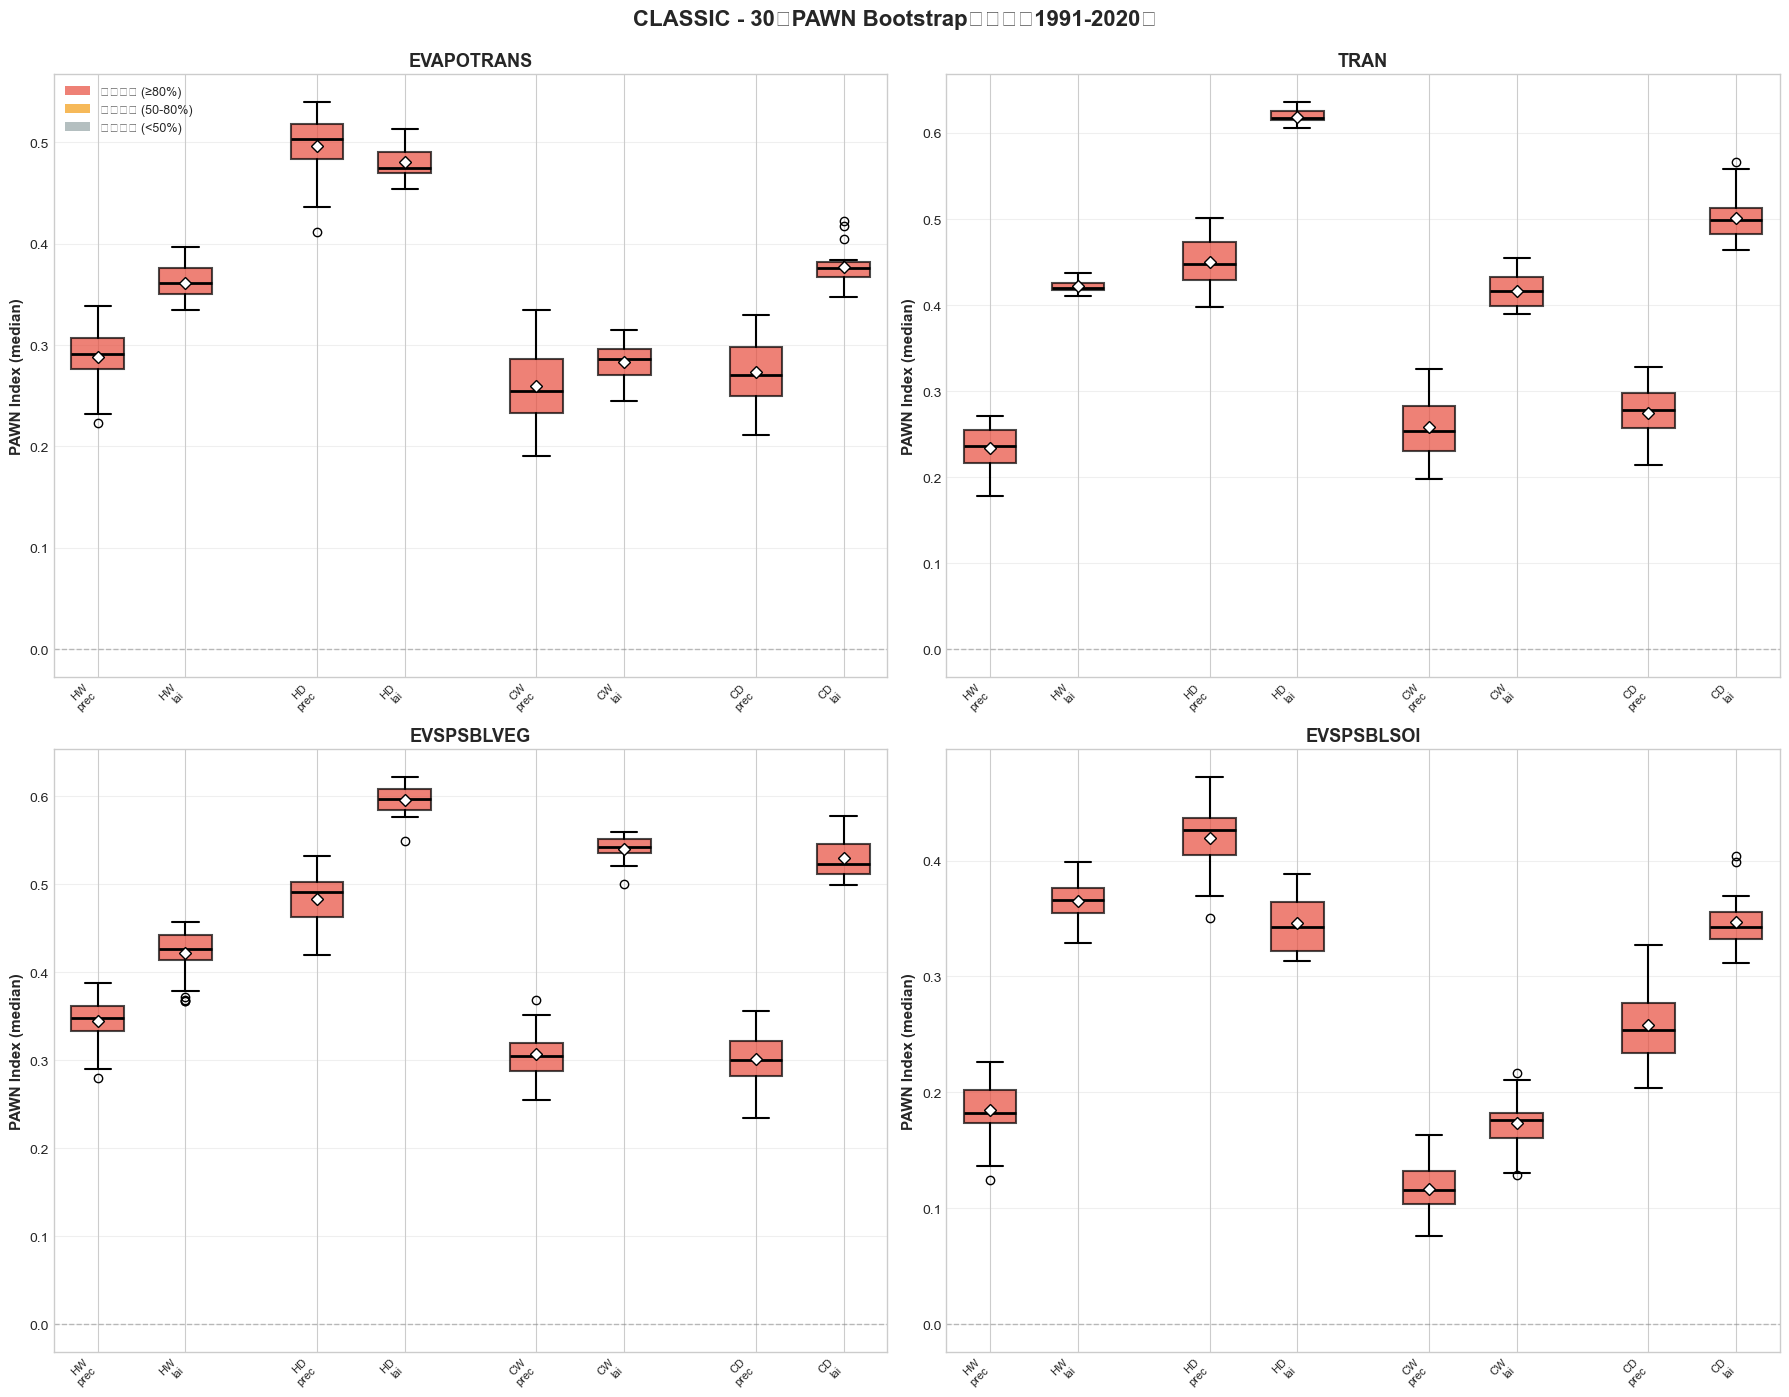

绘制LPJ-GUESS 30年Bootstrap箱型图...


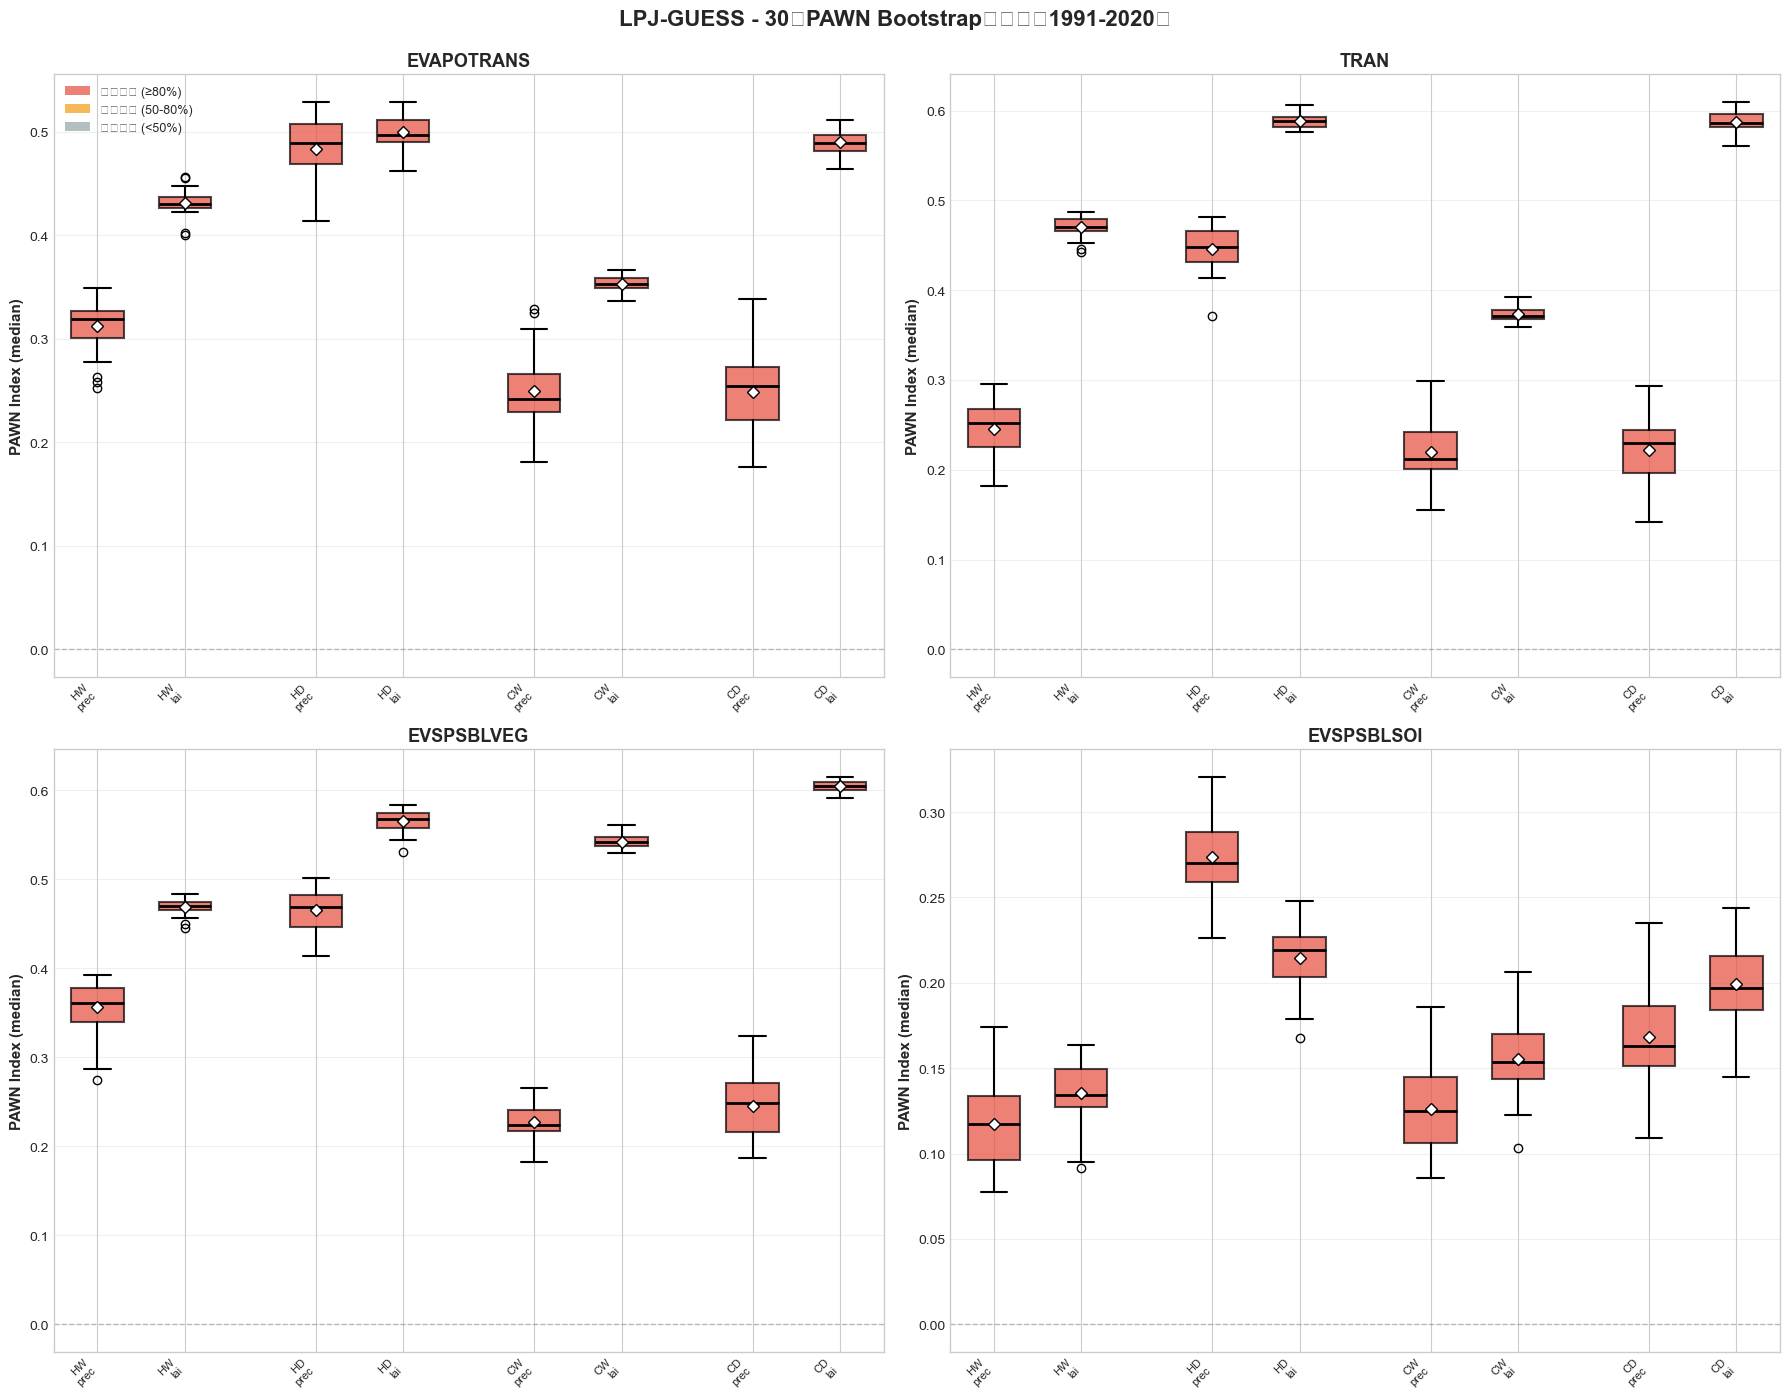

✓ 箱型图已保存


In [13]:
def plot_bootstrap_ci_boxplot(df, model_name):
    """
    绘制30年PAWN Bootstrap置信区间箱型图
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()
    
    for i, output_var in enumerate(output_vars):
        ax = axes[i]
        
        # 筛选数据
        data = df[df['output_var'] == output_var]
        
        # 准备箱型图数据
        box_data = []
        labels = []
        colors = []
        positions = []
        
        pos = 0
        for zone in climate_zones:
            zone_data = data[data['climate_zone'] == zone]
            for input_var in input_vars:
                input_data = zone_data[zone_data['input_var'] == input_var]
                
                if len(input_data) > 0:
                    # 获取30年的PAWN值
                    pawn_values = input_data['pawn_original'].values
                    box_data.append(pawn_values)
                    labels.append(f"{zone}\n{input_var[:4]}")
                    positions.append(pos)
                    
                    # 根据显著性比例着色
                    sig_pct = input_data['pawn_significant'].sum() / len(input_data)
                    if sig_pct >= 0.8:
                        colors.append('#e74c3c')  # 红色 - 高度显著
                    elif sig_pct >= 0.5:
                        colors.append('#f39c12')  # 橙色 - 中度显著
                    else:
                        colors.append('#95a5a6')  # 灰色 - 低显著性
                    
                    pos += 1
            pos += 0.5  # 气候区之间留空隙
        
        # 绘制箱型图
        bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                        patch_artist=True,
                        showmeans=True,
                        meanprops=dict(marker='D', markerfacecolor='white', 
                                      markeredgecolor='black', markersize=6),
                        medianprops=dict(color='black', linewidth=2),
                        boxprops=dict(linewidth=1.5),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5))
        
        # 设置每个箱子的颜色
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
        ax.set_ylabel('PAWN Index (median)', fontsize=11, fontweight='bold')
        ax.set_title(f"{output_var.upper()}", fontsize=13, fontweight='bold')
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(axis='y', alpha=0.3)
        
        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#e74c3c', alpha=0.7, label='高度显著 (≥80%)'),
            Patch(facecolor='#f39c12', alpha=0.7, label='中度显著 (50-80%)'),
            Patch(facecolor='#95a5a6', alpha=0.7, label='低显著性 (<50%)')
        ]
        if i == 0:
            ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    
    fig.suptitle(f"{model_name} - 30年PAWN Bootstrap箱型图（1991-2020）",
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC
print("绘制CLASSIC 30年Bootstrap箱型图...")
fig1 = plot_bootstrap_ci_boxplot(classic_bootstrap_df, 'CLASSIC')
fig1.savefig(output_dir / 'classic_bootstrap_30y_boxplot.png', bbox_inches='tight', dpi=300)
plt.show()

# 绘制LPJ-GUESS
print("绘制LPJ-GUESS 30年Bootstrap箱型图...")
fig2 = plot_bootstrap_ci_boxplot(lpj_bootstrap_df, 'LPJ-GUESS')
fig2.savefig(output_dir / 'lpj_bootstrap_30y_boxplot.png', bbox_inches='tight', dpi=300)
plt.show()

print("✓ 箱型图已保存")

## 8. 可视化：显著性比例热图

绘制CLASSIC显著性热图...


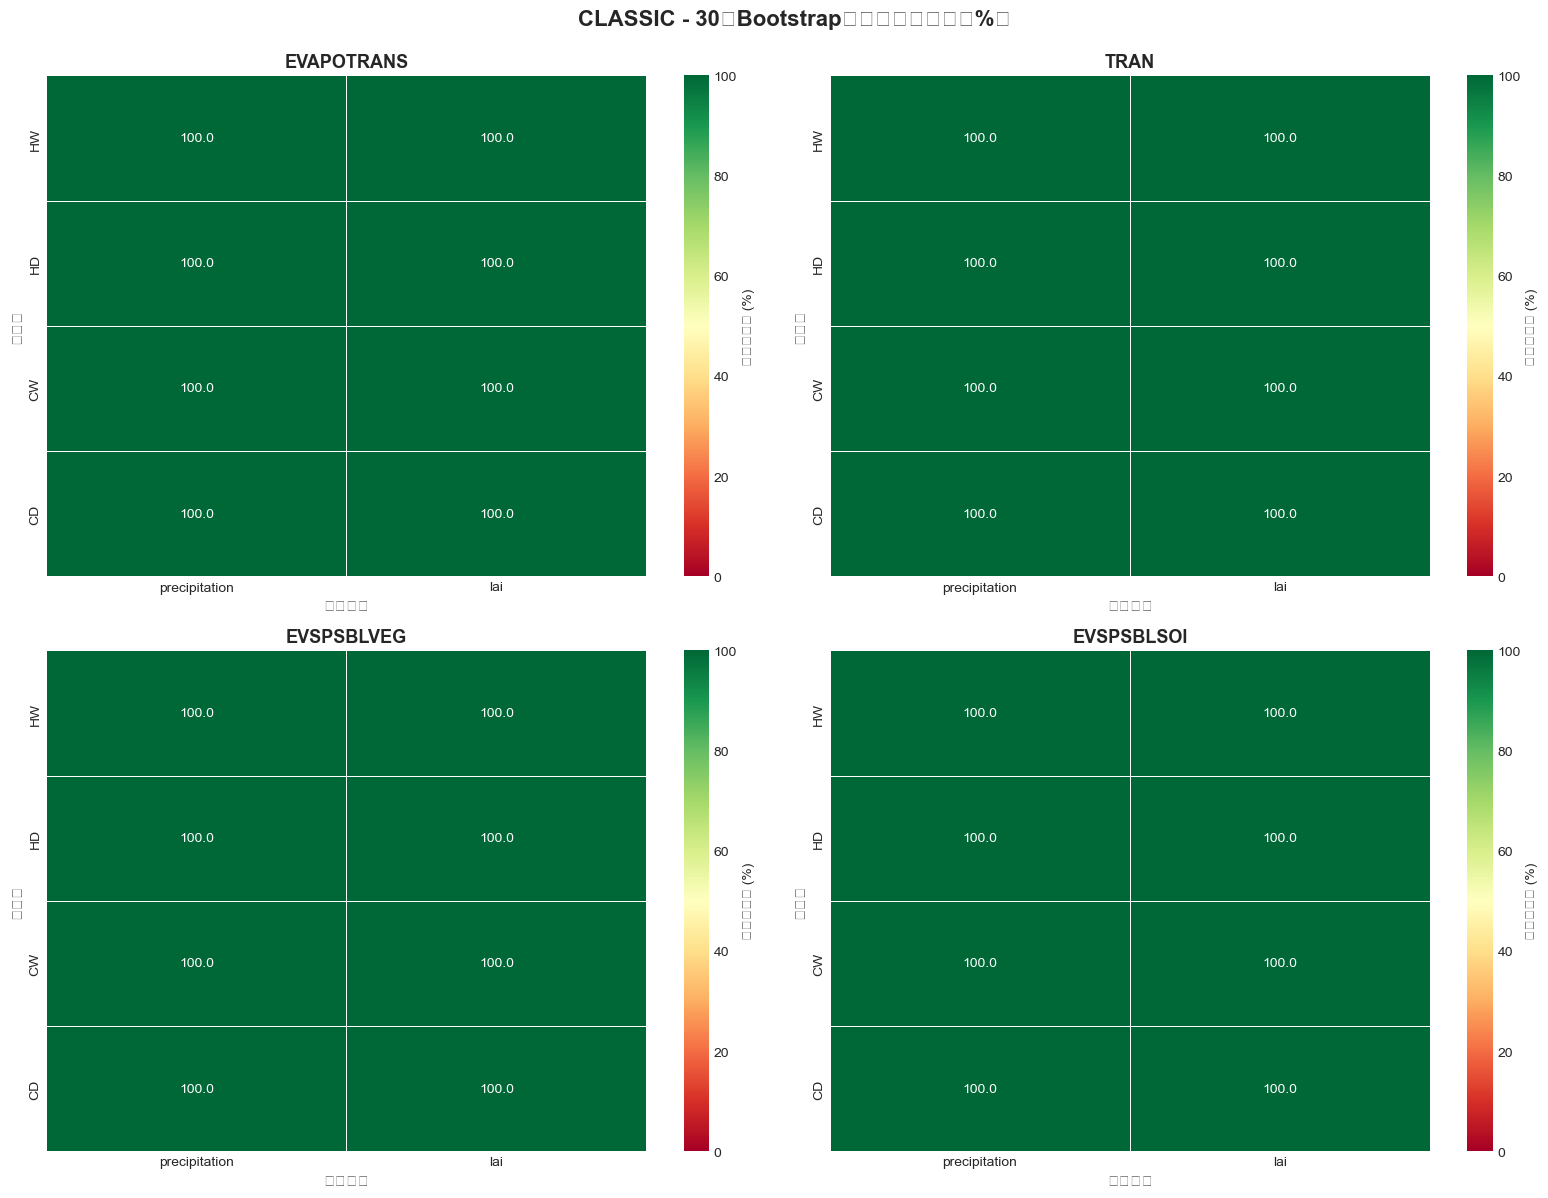

绘制LPJ-GUESS显著性热图...


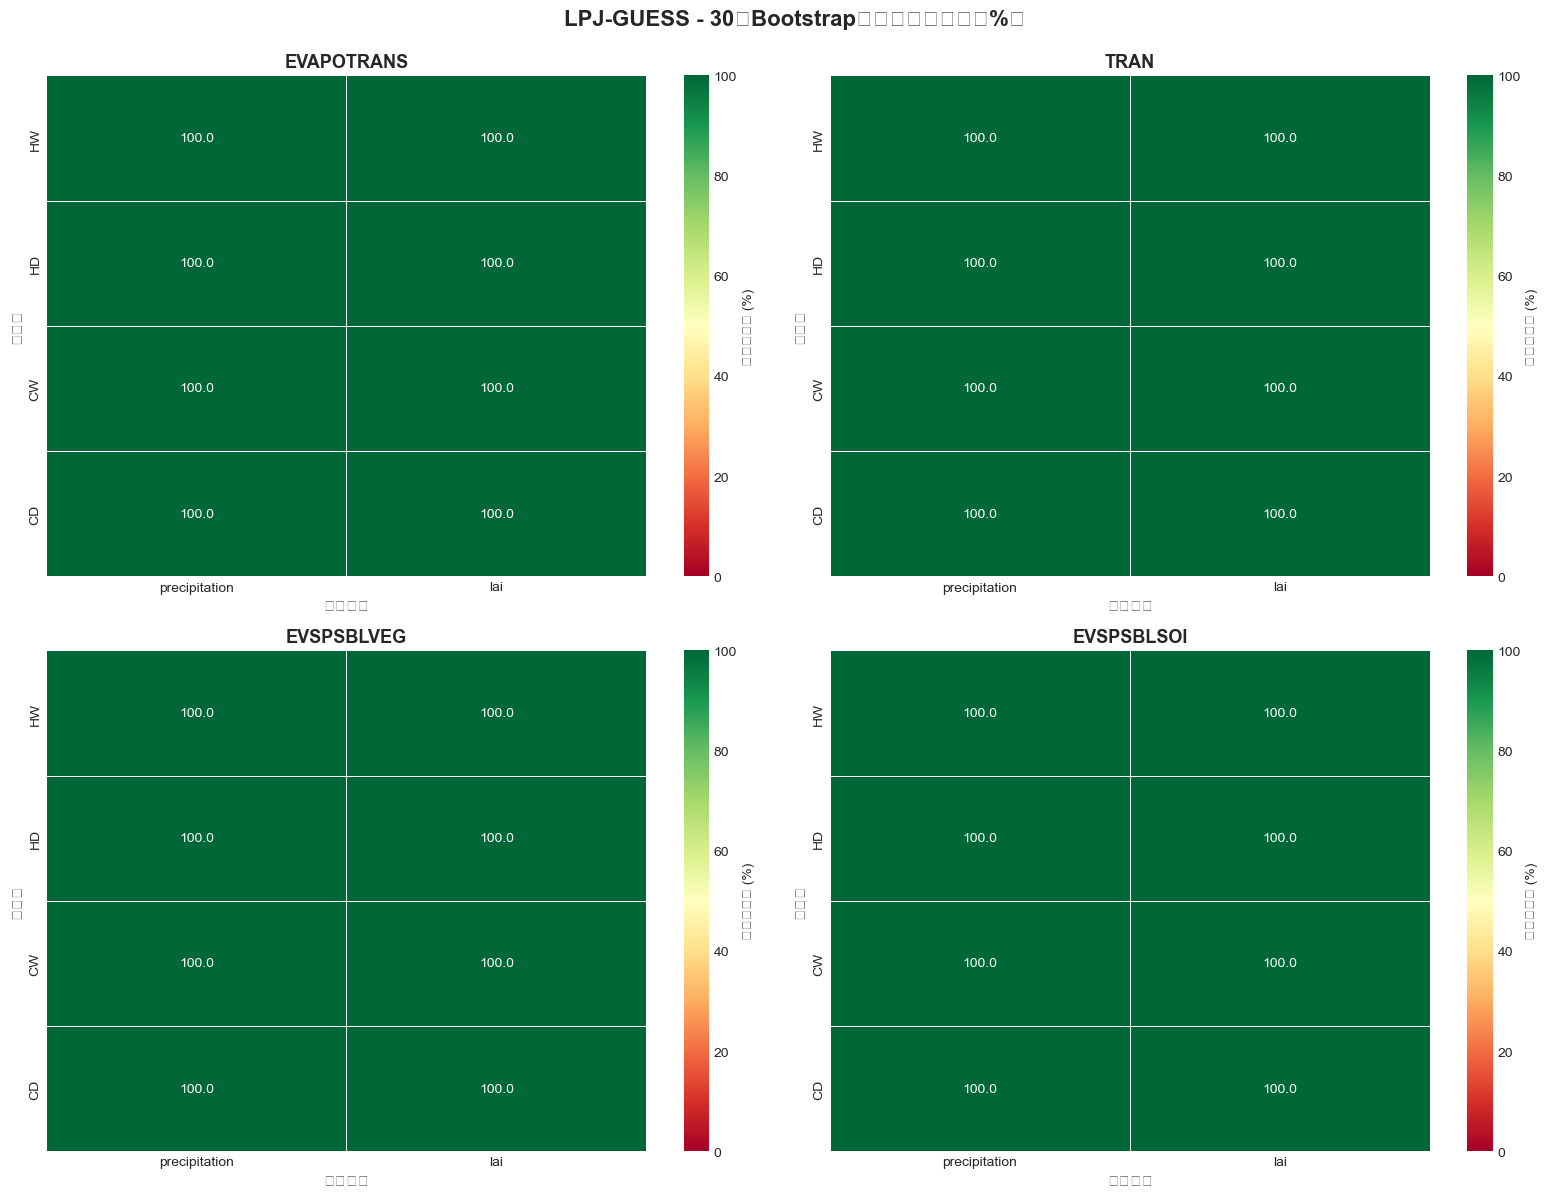

✓ 热图已保存


In [14]:
def plot_significance_heatmap(df, model_name):
    """
    绘制显著性比例热图（气候区 × 输入变量）
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, output_var in enumerate(output_vars):
        ax = axes[i]
        
        # 筛选数据
        data = df[df['output_var'] == output_var]
        
        # 计算显著性比例
        sig_matrix = []
        for zone in climate_zones:
            zone_row = []
            zone_data = data[data['climate_zone'] == zone]
            for input_var in input_vars:
                input_data = zone_data[zone_data['input_var'] == input_var]
                if len(input_data) > 0:
                    sig_pct = input_data['pawn_significant'].sum() / len(input_data) * 100
                    zone_row.append(sig_pct)
                else:
                    zone_row.append(0)
            sig_matrix.append(zone_row)
        
        # 转换为DataFrame
        sig_df = pd.DataFrame(sig_matrix, index=climate_zones, columns=input_vars)
        
        # 绘制热图
        sns.heatmap(sig_df, annot=True, fmt='.1f', cmap='RdYlGn',
                   vmin=0, vmax=100, cbar_kws={'label': '显著性比例 (%)'},
                   linewidths=0.5, ax=ax)
        
        ax.set_xlabel('输入变量', fontsize=11, fontweight='bold')
        ax.set_ylabel('气候区', fontsize=11, fontweight='bold')
        ax.set_title(f"{output_var.upper()}", fontsize=13, fontweight='bold')
    
    fig.suptitle(f"{model_name} - 30年Bootstrap显著性比例热图（%）",
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return fig

# 绘制CLASSIC
print("绘制CLASSIC显著性热图...")
fig3 = plot_significance_heatmap(classic_bootstrap_df, 'CLASSIC')
fig3.savefig(output_dir / 'classic_bootstrap_significance_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# 绘制LPJ-GUESS
print("绘制LPJ-GUESS显著性热图...")
fig4 = plot_significance_heatmap(lpj_bootstrap_df, 'LPJ-GUESS')
fig4.savefig(output_dir / 'lpj_bootstrap_significance_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

print("✓ 热图已保存")

## 9. 导出结果

In [15]:
# 导出Bootstrap结果
classic_bootstrap_df.to_csv(output_dir / 'classic_bootstrap_30y_results.csv', index=False)
lpj_bootstrap_df.to_csv(output_dir / 'lpj_bootstrap_30y_results.csv', index=False)
all_bootstrap_results.to_csv(output_dir / 'all_bootstrap_30y_results.csv', index=False)

print("✓ 所有结果已导出到:", output_dir)
print("\n生成的文件:")
for f in sorted(output_dir.glob('*')):
    print(f"  - {f.name}")

✓ 所有结果已导出到: output\bootstrap_30y_PAWN

生成的文件:
  - all_bootstrap_30y_results.csv
  - bootstrap_30y_average.csv
  - classic_bootstrap_30y_boxplot.png
  - classic_bootstrap_30y_results.csv
  - classic_bootstrap_significance_heatmap.png
  - lpj_bootstrap_30y_boxplot.png
  - lpj_bootstrap_30y_results.csv
  - lpj_bootstrap_significance_heatmap.png


## 10. 分析总结

In [ ]:
print("="*80)
print("30年PAWN Bootstrap验证分析完成！")
print("="*80)

print("\n分析配置:")
print(f"  Bootstrap重采样次数: {N_BOOTSTRAP}")
print(f"  置信水平: {CONFIDENCE_LEVEL}")
print(f"  分析方法: PAWN")
print(f"  时间范围: {years[0]}-{years[-1]} ({len(years)}年)")

print("\n分析范围:")
print(f"  模型: CLASSIC, LPJ-GUESS")
print(f"  气候区: {', '.join(climate_zones)}")
print(f"  输入变量: {', '.join(input_vars)}")
print(f"  输出变量: {', '.join(output_vars)}")
print(f"  总计测试: {len(all_bootstrap_results):,} 个年份-气候区-变量组合")

print("\n主要发现:")
print("  1. 30年逐年Bootstrap置信区间已计算")
print("  2. 统计显著性已评估 (p<0.05)")
print("  3. 30年平均Bootstrap统计量已计算")
print("  4. 显著性比例热图已生成")
print("  5. 结果已保存到CSV文件")

print(f"\n输出目录: {output_dir}")
print("\n✓ 分析完成！")